# Análisis de Impacto del Incremento del Diésel y Tipo de Cambio en SOBOCE S.A.

**Versión corregida y completada para la defensa del proyecto de Minería de Datos (CRISP-DM).**

Este notebook organiza el trabajo de acuerdo con las preguntas de evaluación: entendimiento del negocio, entendimiento y preparación de los datos, exploración y modelado de clasificación.

> **Importante:** la hoja metodológica del archivo Excel indica que la base es **simulada/sintética**, construida para fines académicos y anclada a precios, tipo de cambio e hitos regulatorios. Por tanto, los resultados del modelo no deben presentarse como cifras oficiales de SOBOCE.

## 1. Entendimiento del negocio

El proyecto estudia cómo el incremento del precio del diésel afecta el costo operativo de SOBOCE, especialmente por el consumo en maquinaria y transporte. El análisis busca apoyar decisiones de **optimización logística, reducción del consumo de combustible y evaluación de alternativas energéticas**.

La métrica principal de negocio es el **Costo de Diésel Operativo por Tonelada Producida (CDO_Ton)**, expresada en **Bs/Ton**.

La meta documentada del proyecto para el escenario actual es reducir el CDO_Ton de aproximadamente **102,85 Bs/Ton** a **78,50 Bs/Ton**, equivalente a una reducción cercana al **23,7 %**.

**No confundir:**
- `Costo_Diesel_por_Ton` es una **métrica de negocio**.
- `Accuracy`, `Precision`, `Recall` y `F1` son **métricas de desempeño del modelo de clasificación**.

In [1]:
# Importación de librerías
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 180)

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 2. Carga de datos y unidad de análisis

La unidad de análisis es **un registro operativo diario de producción/distribución asociado a una planta**, con variables de fecha, planta, región de destino, tipo de cemento, producción, transporte, consumo de diésel, costos y contexto económico.

La hoja metodológica señala que la base contiene **10.000 registros sintéticos**, con cobertura del **13/07/2017 al 28/08/2026**. El conjunto original posee **31 variables**.

In [2]:
# Localización automática del archivo Excel
posibles = [
    Path('Impacto_Diesel_Cementera_SOBOCE (2).xlsx'),
    Path('../Data/Impacto_Diesel_Cementera_SOBOCE (2).xlsx')
]

file_path = next((p for p in posibles if p.exists()), None)
if file_path is None:
    candidatos = list(Path('.').glob('*Impacto_Diesel_Cementera_SOBOCE*.xlsx'))
    if not candidatos:
        raise FileNotFoundError('No se encontró el archivo Excel de SOBOCE en la carpeta actual ni en ../Data.')
    file_path = candidatos[0]

# Lectura de la hoja principal y de las notas metodológicas
df = pd.read_excel(file_path, sheet_name='Datos_SOBOCE_Bolivia')
notas = pd.read_excel(file_path, sheet_name='Notas_Metodologicas', header=None)

filas_originales, columnas_originales = df.shape
print(f'Archivo cargado: {file_path.name}')
print(f'Dimensiones originales: {filas_originales:,} registros x {columnas_originales} variables')
print(f'Rango de fecha original: {df["Fecha"].min()} a {df["Fecha"].max()}')

df.head()

Archivo cargado: Impacto_Diesel_Cementera_SOBOCE (2).xlsx
Dimensiones originales: 10,000 registros x 31 variables
Rango de fecha original: 2017-07-13 a 2026-08-28


,ID,Fecha,Pais,Empresa,Planta,Region_Destino,Tipo_Cemento,Categoria_Consumidor_Diesel,Categoria_Precio_Diesel,Evento_Regulatorio,Precio_Diesel_Usuario_Normal_Bs_Litro,Precio_Diesel_Gran_Consumidor_Bs_Litro,Precio_Diesel_Aplicado_SOBOCE_Bs_Litro,Tipo_Cambio_Oficial_BOB_USD,Tipo_Cambio_Paralelo_BOB_USD,Volumen_Produccion_Ton,Volumen_Ventas_Ton,Distancia_Prom_Transporte_Km,Consumo_Diesel_Maquinaria_L,Consumo_Diesel_Transporte_L,Consumo_Diesel_Total_L,Costo_Diesel_Total_Bs,Costo_Diesel_Total_USD,Costo_Transporte_Bs_Ton,Costo_Produccion_Bs_Ton,Precio_Venta_Cemento_Bs_Bolsa50kg,Margen_Bruto_Pct,Emisiones_CO2_Ton,Num_Vehiculos_Transporte,Horas_Operacion_Maquinaria,Inflacion_Mensual_Pct
0,1,2017-07-13,Bolivia,SOBOCE S.A.,Viacha (La Paz),Oruro,HE (Alta Resistencia),Gran Consumidor (GRACO),Único (subsidiado),Pre-shock: subsidio pleno vigente (~3.74 Bs/L ...,3.75,3.75,3.75,6.96,7.06,2890.9,2893.1,89.6,5386.9,8424.6,13811.6,51793.33,7441.57,10.92,450.45,63.20,64.36,37.01,93,18.9,0.21
1,2,2017-07-13,Bolivia,SOBOCE S.A.,El Puente (Tarija),Santa Cruz,HE (Alta Resistencia),Gran Consumidor (GRACO),Único (subsidiado),Pre-shock: subsidio pleno vigente (~3.74 Bs/L ...,3.75,3.75,3.75,6.96,7.06,2695.2,2742.0,162.9,4402.3,12641.3,17043.5,63913.17,9182.93,17.29,441.67,63.15,65.03,45.68,97,17.0,0.35
2,3,2017-07-13,Bolivia,SOBOCE S.A.,Warnes (Santa Cruz),Chuquisaca,IP-30,Gran Consumidor (GRACO),Único (subsidiado),Pre-shock: subsidio pleno vigente (~3.74 Bs/L ...,3.74,3.76,3.76,6.96,7.06,2832.4,2755.4,166.0,5144.6,15050.6,20195.2,75933.98,10910.05,20.54,448.23,61.50,63.56,54.12,92,18.3,0.57
3,4,2017-07-14,Bolivia,SOBOCE S.A.,Viacha (La Paz),Chuquisaca,IP-40,Gran Consumidor (GRACO),Único (subsidiado),Pre-shock: subsidio pleno vigente (~3.74 Bs/L ...,3.75,3.75,3.75,6.96,7.12,2507.4,2508.0,78.2,3653.9,6412.6,10066.5,37749.28,5423.75,9.59,444.42,59.98,62.95,26.98,82,18.4,0.68
4,5,2017-07-14,Bolivia,SOBOCE S.A.,El Puente (Tarija),Oruro,IP-30,Gran Consumidor (GRACO),Único (subsidiado),Pre-shock: subsidio pleno vigente (~3.74 Bs/L ...,3.75,3.76,3.76,6.96,7.12,2748.1,2608.8,129.0,3927.5,10083.8,14011.2,52682.25,7569.29,14.53,432.76,63.54,65.94,37.55,85,18.4,0.69


## 3. Calidad y preparación de los datos

Se verifican valores faltantes, duplicados, fechas inválidas, valores no positivos en campos que deben ser positivos y coherencia básica entre consumos/costos relacionados.

Si no existen problemas que obliguen a eliminar filas, se mantienen los **10.000 registros**. Las pequeñas diferencias entre sumas de consumo o costo calculado y columnas almacenadas se consideran diferencias de **redondeo**, no datos faltantes.

In [3]:
# 3.1 Valores faltantes
faltantes = df.isna().sum()
faltantes_con_valor = faltantes[faltantes > 0]

print('VALORES FALTANTES')
print(f'Total de valores faltantes: {int(faltantes.sum())}')
if faltantes_con_valor.empty:
    print('Columnas con valores faltantes: Ninguna')
else:
    print('Columnas con valores faltantes:')
    print(faltantes_con_valor)

# 3.2 Duplicados exactos
duplicados = int(df.duplicated().sum())
print(f'\nRegistros duplicados exactos: {duplicados}')

# 3.3 Conversión de fecha y validación
df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
fechas_invalidas = int(df['Fecha'].isna().sum())
print(f'Fechas inválidas después de la conversión: {fechas_invalidas}')

# 3.4 Validación de variables que deben ser positivas
columnas_positivas = [
    'Volumen_Produccion_Ton',
    'Consumo_Diesel_Maquinaria_L',
    'Consumo_Diesel_Transporte_L',
    'Consumo_Diesel_Total_L',
    'Costo_Diesel_Total_Bs',
    'Precio_Diesel_Aplicado_SOBOCE_Bs_Litro'
]

problemas_positividad = {
    c: int((df[c] <= 0).sum()) for c in columnas_positivas
}
print('\nValores <= 0 en campos que deberían ser positivos:')
for c, n in problemas_positividad.items():
    print(f'  {c}: {n}')

# 3.5 Consistencia por redondeo
error_consumo = (
    df['Consumo_Diesel_Total_L']
    - (df['Consumo_Diesel_Maquinaria_L'] + df['Consumo_Diesel_Transporte_L'])
).abs()

error_costo = (
    df['Costo_Diesel_Total_Bs']
    - df['Consumo_Diesel_Total_L'] * df['Precio_Diesel_Aplicado_SOBOCE_Bs_Litro']
).abs()

print(f'\nMáxima diferencia Consumo Total vs. Maquinaria + Transporte: {error_consumo.max():.3f} L')
print(f'Máxima diferencia Costo Total vs. Consumo Total × Precio: {error_costo.max():.3f} Bs')
print('Estas diferencias son pequeñas y compatibles con redondeo de los datos sintéticos.')

# Preparación final: ordenar por fecha. No se eliminan filas porque no hay faltantes,
# duplicados ni denominadores inválidos que obliguen a hacerlo.
df = df.sort_values('Fecha').reset_index(drop=True)
print(f'\nRegistros después de la preparación: {len(df):,}')

VALORES FALTANTES
Total de valores faltantes: 0
Columnas con valores faltantes: Ninguna

Registros duplicados exactos: 0
Fechas inválidas después de la conversión: 0

Valores <= 0 en campos que deberían ser positivos:
  Volumen_Produccion_Ton: 0
  Consumo_Diesel_Maquinaria_L: 0
  Consumo_Diesel_Transporte_L: 0
  Consumo_Diesel_Total_L: 0
  Costo_Diesel_Total_Bs: 0
  Precio_Diesel_Aplicado_SOBOCE_Bs_Litro: 0

Máxima diferencia Consumo Total vs. Maquinaria + Transporte: 0.100 L
Máxima diferencia Costo Total vs. Consumo Total × Precio: 0.851 Bs
Estas diferencias son pequeñas y compatibles con redondeo de los datos sintéticos.

Registros después de la preparación: 10,000


### Observación de consistencia documental

En el Excel utilizado, la categoría **“Segmentado (DS 5676 - precio internacional)”** contiene **34 registros**. El documento del proyecto presenta “341” en una tabla; para este notebook se usa el conteo real del archivo Excel. Los promedios del escenario DS 5676 sí coinciden con esos 34 registros.

In [4]:
conteo_regimen = df['Categoria_Precio_Diesel'].value_counts()
print('Registros por régimen tarifario:')
print(conteo_regimen)

Registros por régimen tarifario:
Categoria_Precio_Diesel
Único (subsidiado)                             9027
Único (post-subsidio)                           726
Segmentado (ULS+ industrial)                    213
Segmentado (DS 5676 - precio internacional)      34
Name: count, dtype: int64


## 4. Métrica principal de negocio (KPI)

La métrica se calcula como:

\[
CDO\_Ton = \frac{Costo\_Diesel\_Total\_Bs}{Volumen\_Produccion\_Ton}
\]

- **Numerador:** costo total de diésel, en **Bs**.
- **Denominador:** volumen de producción, en **Ton**.
- **Resultado:** costo de diésel por tonelada producida, en **Bs/Ton**.

De forma equivalente, el costo total puede entenderse como consumo total de diésel multiplicado por el precio aplicado del combustible.

In [5]:
# Creación del KPI
if (df['Volumen_Produccion_Ton'] <= 0).any():
    raise ValueError('Existen volúmenes de producción <= 0; no se puede calcular el KPI con seguridad.')

df['Costo_Diesel_por_Ton'] = df['Costo_Diesel_Total_Bs'] / df['Volumen_Produccion_Ton']

# Promedio histórico sobre los 10.000 registros
promedio_historico_kpi = df['Costo_Diesel_por_Ton'].mean()

# Escenario vigente DS 5676 dentro de la base
mask_ds5676 = df['Categoria_Precio_Diesel'].str.contains('DS 5676', case=False, na=False)
df_ds5676 = df.loc[mask_ds5676].copy()
promedio_ds5676_kpi = df_ds5676['Costo_Diesel_por_Ton'].mean()

# Meta de negocio documentada
meta_negocio = 78.50
reduccion_objetivo = (promedio_ds5676_kpi - meta_negocio) / promedio_ds5676_kpi * 100

print(f'KPI promedio histórico (10.000 registros): {promedio_historico_kpi:.2f} Bs/Ton')
print(f'Registros del escenario DS 5676: {len(df_ds5676)}')
print(f'KPI promedio observado en DS 5676: {promedio_ds5676_kpi:.2f} Bs/Ton')
print(f'Meta de negocio: {meta_negocio:.2f} Bs/Ton')
print(f'Reducción necesaria desde DS 5676 hasta la meta: {reduccion_objetivo:.1f}%')

KPI promedio histórico (10.000 registros): 25.41 Bs/Ton
Registros del escenario DS 5676: 34
KPI promedio observado en DS 5676: 102.85 Bs/Ton
Meta de negocio: 78.50 Bs/Ton
Reducción necesaria desde DS 5676 hasta la meta: 23.7%


**Interpretación para la defensa:** el promedio histórico de toda la base es aproximadamente **25,41 Bs/Ton**, pero el valor más representativo del problema actual es el promedio del escenario **DS 5676: 102,85 Bs/Ton**. La acción propuesta es reducir ese costo mediante optimización de rutas, mayor eficiencia logística y evaluación de sustitución energética, sin sacrificar el volumen de producción.

## 5. Exploración de los datos

Se muestran dos hallazgos relacionados directamente con el objetivo del proyecto:

1. El **transporte concentra la mayor parte del consumo promedio de diésel**.
2. El **costo de diésel por tonelada aumenta fuertemente en los regímenes de mayor precio**, especialmente en el escenario DS 5676.

Consumo promedio maquinaria: 4,237.53 L (28.2%)
Consumo promedio transporte: 10,793.27 L (71.8%)


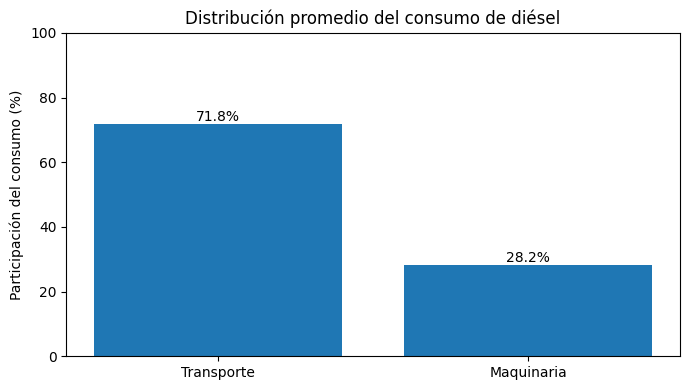

In [6]:
# 5.1 Participación del consumo promedio de diésel
prom_maq = df['Consumo_Diesel_Maquinaria_L'].mean()
prom_trans = df['Consumo_Diesel_Transporte_L'].mean()
total_componentes = prom_maq + prom_trans
pct_maq = prom_maq / total_componentes * 100
pct_trans = prom_trans / total_componentes * 100

print(f'Consumo promedio maquinaria: {prom_maq:,.2f} L ({pct_maq:.1f}%)')
print(f'Consumo promedio transporte: {prom_trans:,.2f} L ({pct_trans:.1f}%)')

fig, ax = plt.subplots(figsize=(7, 4))
valores = [pct_trans, pct_maq]
etiquetas = ['Transporte', 'Maquinaria']
ax.bar(etiquetas, valores)
ax.set_title('Distribución promedio del consumo de diésel')
ax.set_ylabel('Participación del consumo (%)')
ax.set_ylim(0, 100)
for i, v in enumerate(valores):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center')
plt.tight_layout()
plt.show()

Costo de diésel por tonelada promedio según régimen:
Categoria_Precio_Diesel
Único (subsidiado)                              21.92
Segmentado (ULS+ industrial)                    51.54
Único (post-subsidio)                           57.49
Segmentado (DS 5676 - precio internacional)    102.85
Name: Costo_Diesel_por_Ton, dtype: float64


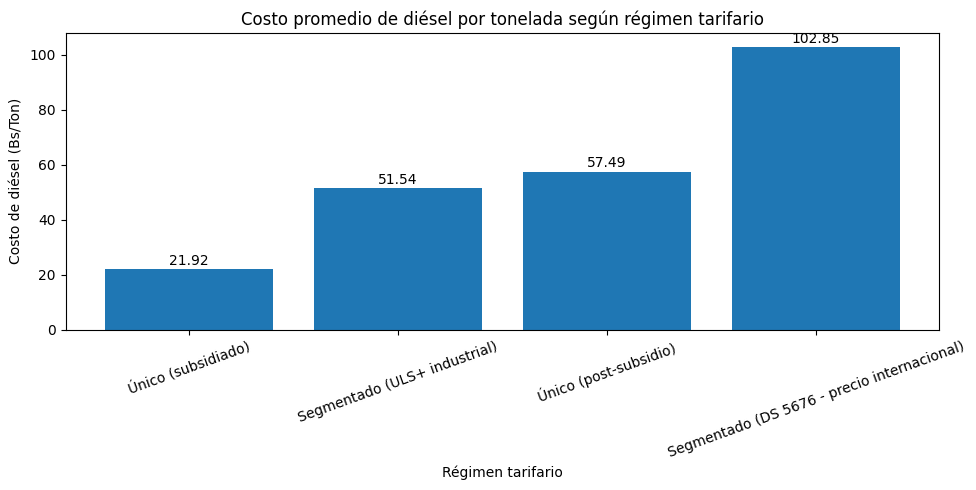

In [7]:
# 5.2 KPI promedio por régimen tarifario
orden_regimen = [
    'Único (subsidiado)',
    'Segmentado (ULS+ industrial)',
    'Único (post-subsidio)',
    'Segmentado (DS 5676 - precio internacional)'
]

kpi_regimen = (
    df.groupby('Categoria_Precio_Diesel')['Costo_Diesel_por_Ton']
      .mean()
      .reindex(orden_regimen)
      .dropna()
)

print('Costo de diésel por tonelada promedio según régimen:')
print(kpi_regimen.round(2))

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(kpi_regimen.index, kpi_regimen.values)
ax.set_title('Costo promedio de diésel por tonelada según régimen tarifario')
ax.set_ylabel('Costo de diésel (Bs/Ton)')
ax.set_xlabel('Régimen tarifario')
ax.tick_params(axis='x', rotation=20)
for i, v in enumerate(kpi_regimen.values):
    ax.text(i, v + 1.5, f'{v:.2f}', ha='center')
plt.tight_layout()
plt.show()

## 6. Variable objetivo para clasificación

El KPI `Costo_Diesel_por_Ton` es continuo. Para responder la parte de **clasificación** de la rúbrica se necesita convertirlo en clases.

Se define `Alto_Impacto_Costo` usando el **percentil 75 (P75)** de la distribución histórica:

- **Clase 0 – Impacto normal:** `Costo_Diesel_por_Ton <= P75`.
- **Clase 1 – Alto impacto:** `Costo_Diesel_por_Ton > P75`.

Este umbral es **solo para la tarea de clasificación** y no reemplaza la meta de negocio de **78,50 Bs/Ton**. El uso del P75 permite identificar el 25 % de registros históricamente más costosos y disponer de suficientes casos en ambas clases para entrenar y evaluar un clasificador.

In [8]:
# Umbral de clasificación: percentil 75 del KPI histórico
umbral_clasificacion = df['Costo_Diesel_por_Ton'].quantile(0.75)
df['Alto_Impacto_Costo'] = (df['Costo_Diesel_por_Ton'] > umbral_clasificacion).astype(int)

distribucion_clases = df['Alto_Impacto_Costo'].value_counts().sort_index()
porcentaje_clases = df['Alto_Impacto_Costo'].value_counts(normalize=True).sort_index() * 100

print(f'Umbral P75 para clasificación: {umbral_clasificacion:.2f} Bs/Ton')
print('\nDistribución de clases:')
for clase in [0, 1]:
    etiqueta = 'Impacto normal' if clase == 0 else 'Alto impacto'
    print(f'Clase {clase} - {etiqueta}: {distribucion_clases[clase]:,} registros ({porcentaje_clases[clase]:.1f}%)')

print(f'\nDimensiones después de crear KPI y objetivo: {df.shape[0]:,} registros x {df.shape[1]} columnas')

Umbral P75 para clasificación: 27.85 Bs/Ton

Distribución de clases:
Clase 0 - Impacto normal: 7,500 registros (75.0%)
Clase 1 - Alto impacto: 2,500 registros (25.0%)

Dimensiones después de crear KPI y objetivo: 10,000 registros x 33 columnas


## 7. Variables predictoras y separación entrenamiento/prueba

Para evitar **fuga de información**, no se usa como predictor el propio KPI `Costo_Diesel_por_Ton` ni `Costo_Diesel_Total_Bs`, porque estos campos determinan directamente la clase objetivo.

Se utilizan seis variables explicativas disponibles antes de conocer la clasificación final:

- `Volumen_Produccion_Ton`
- `Distancia_Prom_Transporte_Km`
- `Horas_Operacion_Maquinaria`
- `Num_Vehiculos_Transporte`
- `Precio_Diesel_Aplicado_SOBOCE_Bs_Litro`
- `Tipo_Cambio_Paralelo_BOB_USD`

La división es **80 % entrenamiento / 20 % prueba**, con `random_state=42` y `stratify=y` para conservar la proporción de clases.

In [9]:
features = [
    'Volumen_Produccion_Ton',
    'Distancia_Prom_Transporte_Km',
    'Horas_Operacion_Maquinaria',
    'Num_Vehiculos_Transporte',
    'Precio_Diesel_Aplicado_SOBOCE_Bs_Litro',
    'Tipo_Cambio_Paralelo_BOB_USD'
]

X = df[features].copy()
y = df['Alto_Impacto_Costo'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f'Total de registros utilizados: {len(df):,}')
print(f'Entrenamiento: {len(X_train):,} registros ({len(X_train)/len(df)*100:.0f}%)')
print(f'Prueba: {len(X_test):,} registros ({len(X_test)/len(df)*100:.0f}%)')
print('\nDistribución de clases en entrenamiento:')
print(y_train.value_counts().sort_index())
print('\nDistribución de clases en prueba:')
print(y_test.value_counts().sort_index())

Total de registros utilizados: 10,000
Entrenamiento: 8,000 registros (80%)
Prueba: 2,000 registros (20%)

Distribución de clases en entrenamiento:
Alto_Impacto_Costo
0    6000
1    2000
Name: count, dtype: int64

Distribución de clases en prueba:
Alto_Impacto_Costo
0    1500
1     500
Name: count, dtype: int64


## 8. Modelado: Regresión Logística y Árbol de Decisión

Se utilizan **ambos modelos revisados en clase**:

- **Regresión Logística:** estima la probabilidad de pertenecer a la clase de alto impacto. Las variables se estandarizan con `StandardScaler` dentro de un `Pipeline`. El escalado se aprende **solo con el conjunto de entrenamiento**, evitando que la información de prueba influya en el entrenamiento.
- **Árbol de Decisión:** aprende reglas del tipo “si... entonces...”. Se limita a profundidad 4 para que la visualización sea interpretable.

In [10]:
# Regresión Logística con escalado dentro de un Pipeline
modelo_logistico = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=2000, random_state=42))
])
modelo_logistico.fit(X_train, y_train)
pred_log = modelo_logistico.predict(X_test)

# Árbol de Decisión interpretable
modelo_arbol = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=25,
    random_state=42
)
modelo_arbol.fit(X_train, y_train)
pred_arbol = modelo_arbol.predict(X_test)

print('Modelos entrenados correctamente.')

Modelos entrenados correctamente.


## 9. Desempeño del modelo en el conjunto de prueba

Se reportan **Accuracy, Precision, Recall y F1** para la clase 1 (alto impacto), además de la matriz de confusión.

Para este problema, un **falso negativo** es especialmente importante: sería un registro que realmente tiene alto impacto, pero el modelo lo clasifica como impacto normal. Eso podría hacer que una operación costosa no sea priorizada para revisión.

In [11]:
def evaluar_modelo(nombre, y_real, y_pred):
    cm = confusion_matrix(y_real, y_pred)
    return {
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_real, y_pred),
        'Precision': precision_score(y_real, y_pred, zero_division=0),
        'Recall': recall_score(y_real, y_pred, zero_division=0),
        'F1': f1_score(y_real, y_pred, zero_division=0),
        'TN': int(cm[0, 0]),
        'FP': int(cm[0, 1]),
        'FN': int(cm[1, 0]),
        'TP': int(cm[1, 1])
    }

resultados = pd.DataFrame([
    evaluar_modelo('Regresión Logística', y_test, pred_log),
    evaluar_modelo('Árbol de Decisión', y_test, pred_arbol)
])

columnas_pct = ['Accuracy', 'Precision', 'Recall', 'F1']
resultado_mostrar = resultados.copy()
resultado_mostrar[columnas_pct] = resultado_mostrar[columnas_pct].map(lambda x: f'{x*100:.2f}%')
resultado_mostrar

,Modelo,Accuracy,Precision,Recall,F1,TN,FP,FN,TP
0,Regresión Logística,94.70%,90.20%,88.40%,89.29%,1452,48,58,442
1,Árbol de Decisión,94.75%,86.92%,93.00%,89.86%,1430,70,35,465


In [12]:
print('REPORTE DE CLASIFICACIÓN - REGRESIÓN LOGÍSTICA')
print(classification_report(y_test, pred_log, target_names=['Impacto normal', 'Alto impacto']))

print('REPORTE DE CLASIFICACIÓN - ÁRBOL DE DECISIÓN')
print(classification_report(y_test, pred_arbol, target_names=['Impacto normal', 'Alto impacto']))

REPORTE DE CLASIFICACIÓN - REGRESIÓN LOGÍSTICA
                precision    recall  f1-score   support

Impacto normal       0.96      0.97      0.96      1500
  Alto impacto       0.90      0.88      0.89       500

      accuracy                           0.95      2000
     macro avg       0.93      0.93      0.93      2000
  weighted avg       0.95      0.95      0.95      2000

REPORTE DE CLASIFICACIÓN - ÁRBOL DE DECISIÓN
                precision    recall  f1-score   support

Impacto normal       0.98      0.95      0.96      1500
  Alto impacto       0.87      0.93      0.90       500

      accuracy                           0.95      2000
     macro avg       0.92      0.94      0.93      2000
  weighted avg       0.95      0.95      0.95      2000



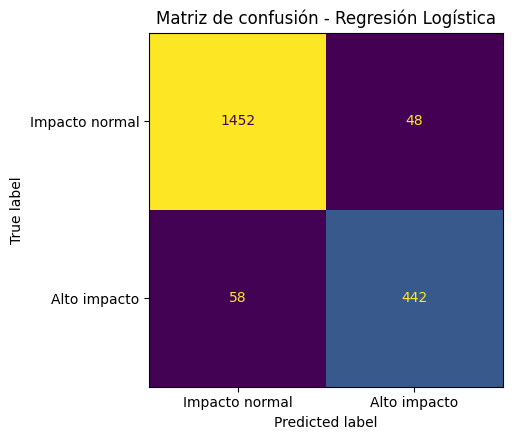

In [13]:
# Matriz de confusión - Regresión Logística
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, pred_log),
    display_labels=['Impacto normal', 'Alto impacto']
).plot(ax=ax, colorbar=False)
ax.set_title('Matriz de confusión - Regresión Logística')
plt.tight_layout()
plt.show()

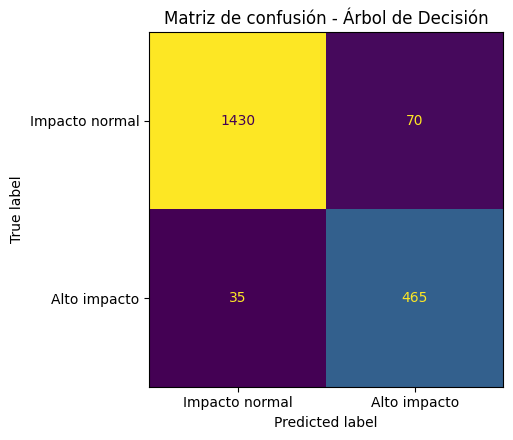

In [14]:
# Matriz de confusión - Árbol de Decisión
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, pred_arbol),
    display_labels=['Impacto normal', 'Alto impacto']
).plot(ax=ax, colorbar=False)
ax.set_title('Matriz de confusión - Árbol de Decisión')
plt.tight_layout()
plt.show()

**Lectura de la matriz:**
- **TN:** impacto normal correctamente identificado.
- **FP:** falsa alarma; era normal, pero el modelo indicó alto impacto.
- **FN:** caso de alto impacto que el modelo no detectó.
- **TP:** alto impacto correctamente detectado.

En este caso, el árbol produce menos falsos negativos que la regresión logística en la partición de prueba, por lo que resulta útil para explicar cómo se identifican casos de alto impacto. Esta comparación corresponde a esta base y a esta partición; no implica causalidad ni garantiza el mismo resultado con datos futuros.

## 10. Variables más importantes e interpretación

En Regresión Logística, los coeficientes se interpretan después de estandarizar las variables; un coeficiente positivo aumenta la tendencia del modelo hacia la clase 1 y uno negativo la disminuye, manteniendo las demás variables constantes dentro del modelo.

En el Árbol de Decisión, `feature_importances_` indica cuánto contribuyó cada variable a las divisiones que reducen la impureza. La importancia es **predictiva**, no una prueba de causalidad.

Coeficientes estandarizados - Regresión Logística:


,Variable,Coeficiente_Estandarizado,Importancia_Absoluta
4,Precio_Diesel_Aplicado_SOBOCE_Bs_Litro,6.098568,6.098568
1,Distancia_Prom_Transporte_Km,5.997706,5.997706
3,Num_Vehiculos_Transporte,0.842235,0.842235
0,Volumen_Produccion_Ton,-0.835305,0.835305
2,Horas_Operacion_Maquinaria,-0.130522,0.130522
5,Tipo_Cambio_Paralelo_BOB_USD,-0.014421,0.014421


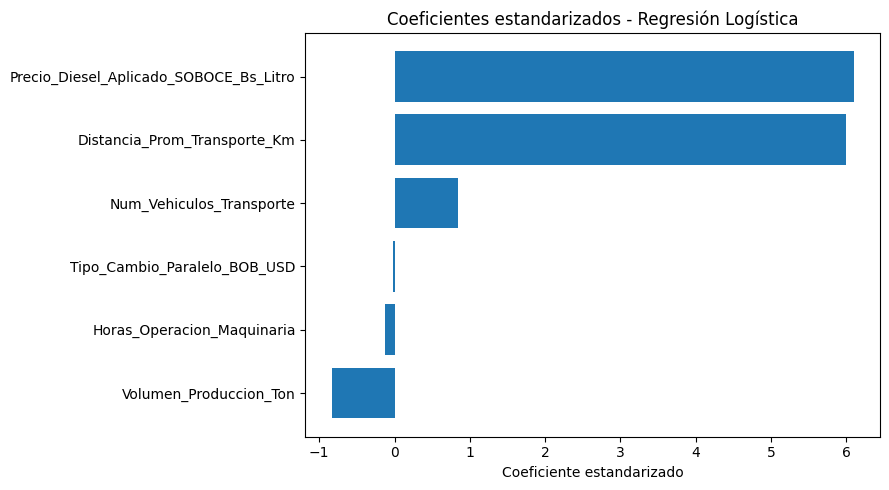

In [15]:
# Coeficientes estandarizados de Regresión Logística
coeficientes = pd.DataFrame({
    'Variable': features,
    'Coeficiente_Estandarizado': modelo_logistico.named_steps['model'].coef_[0]
})
coeficientes['Importancia_Absoluta'] = coeficientes['Coeficiente_Estandarizado'].abs()
coeficientes = coeficientes.sort_values('Importancia_Absoluta', ascending=False)

print('Coeficientes estandarizados - Regresión Logística:')
display(coeficientes)

fig, ax = plt.subplots(figsize=(9, 5))
orden = coeficientes.sort_values('Coeficiente_Estandarizado')
ax.barh(orden['Variable'], orden['Coeficiente_Estandarizado'])
ax.set_title('Coeficientes estandarizados - Regresión Logística')
ax.set_xlabel('Coeficiente estandarizado')
plt.tight_layout()
plt.show()

Importancias - Árbol de Decisión:


,Variable,Importancia
1,Distancia_Prom_Transporte_Km,0.562489
4,Precio_Diesel_Aplicado_SOBOCE_Bs_Litro,0.435393
2,Horas_Operacion_Maquinaria,0.001387
5,Tipo_Cambio_Paralelo_BOB_USD,0.000731
0,Volumen_Produccion_Ton,0.000000
3,Num_Vehiculos_Transporte,0.000000


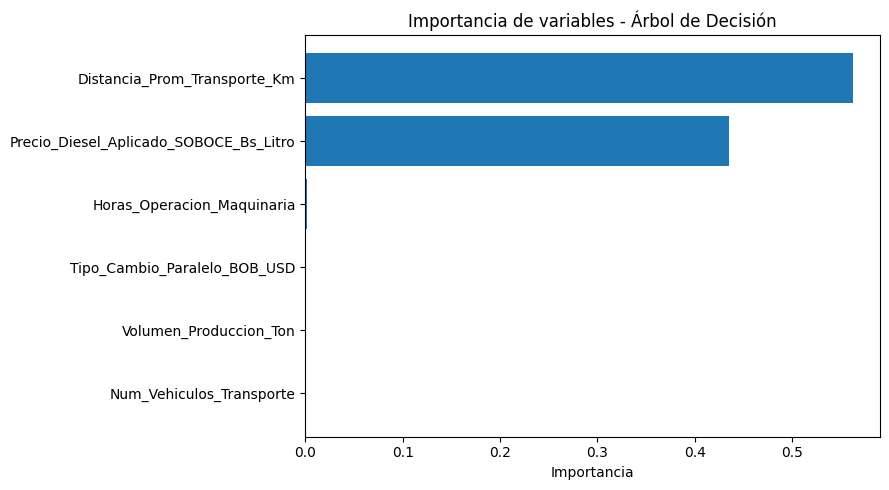

In [16]:
# Importancias del Árbol de Decisión
importancias_arbol = pd.DataFrame({
    'Variable': features,
    'Importancia': modelo_arbol.feature_importances_
}).sort_values('Importancia', ascending=False)

print('Importancias - Árbol de Decisión:')
display(importancias_arbol)

fig, ax = plt.subplots(figsize=(9, 5))
orden = importancias_arbol.sort_values('Importancia')
ax.barh(orden['Variable'], orden['Importancia'])
ax.set_title('Importancia de variables - Árbol de Decisión')
ax.set_xlabel('Importancia')
plt.tight_layout()
plt.show()

## 11. Visualización del Árbol de Decisión

La gráfica permite seguir una ruta desde el nodo superior hasta una clase final. Cada nodo plantea una condición; según se cumpla o no, el registro avanza por una rama diferente.

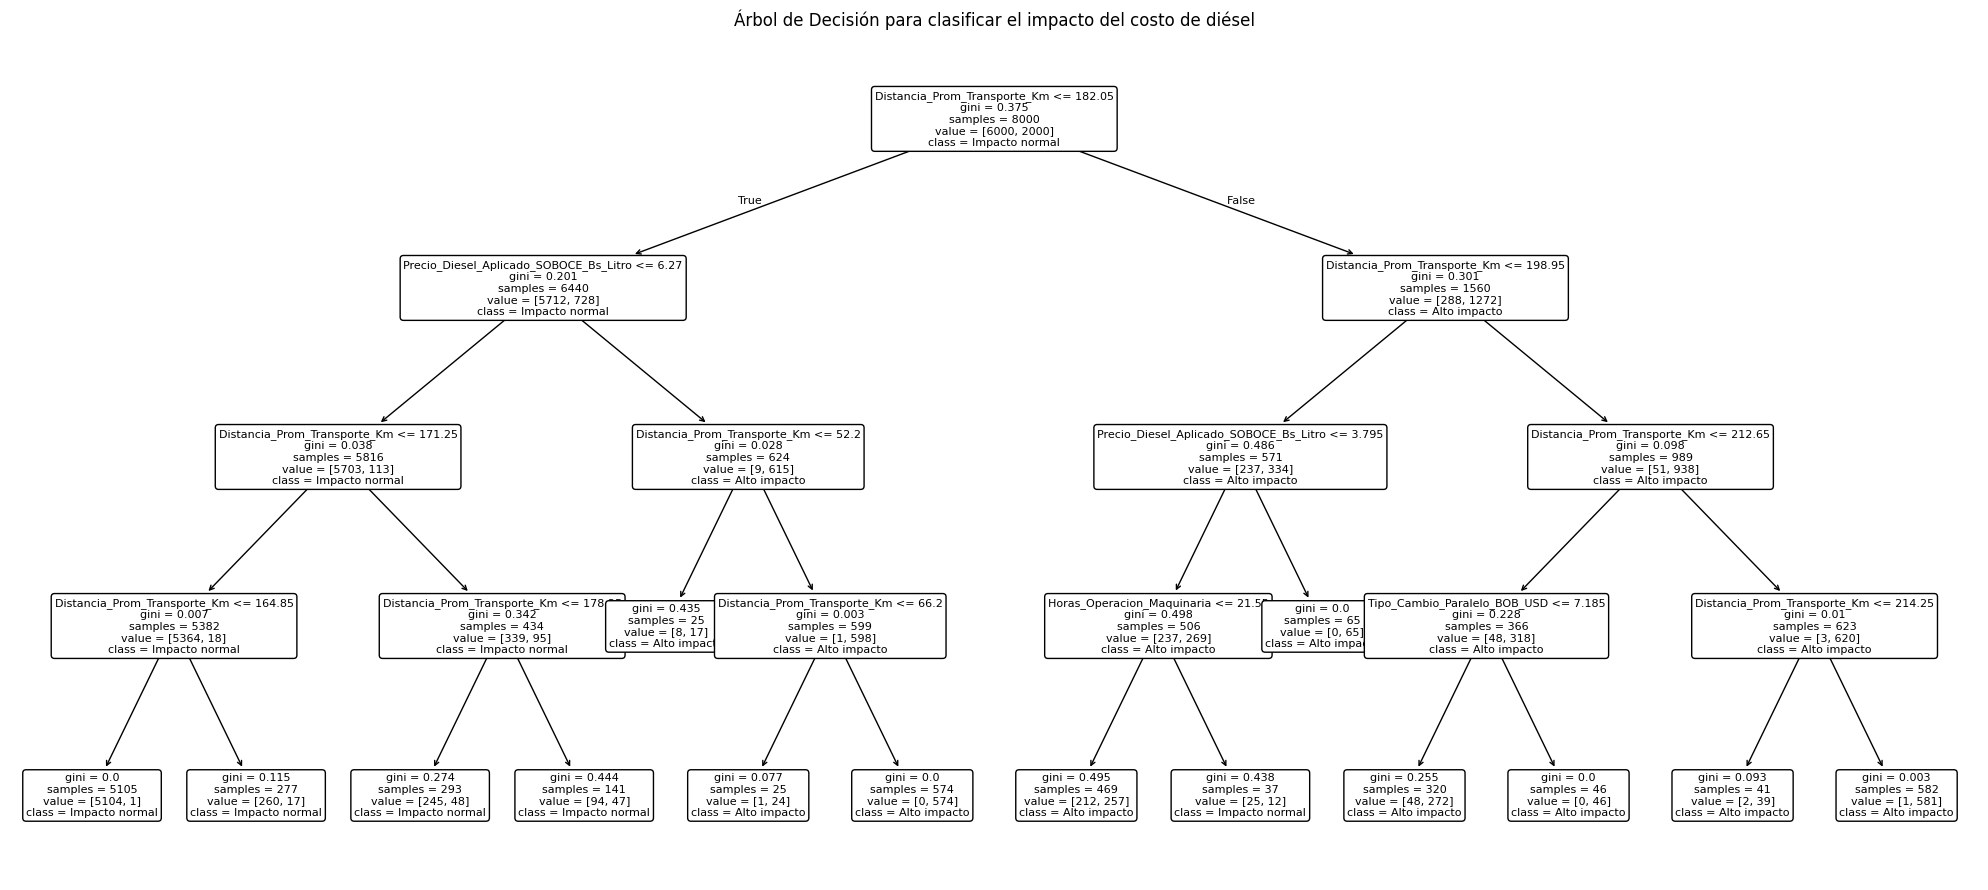

Reglas del árbol en formato texto:
|--- Distancia_Prom_Transporte_Km <= 182.05
|   |--- Precio_Diesel_Aplicado_SOBOCE_Bs_Litro <= 6.27
|   |   |--- Distancia_Prom_Transporte_Km <= 171.25
|   |   |   |--- Distancia_Prom_Transporte_Km <= 164.85
|   |   |   |   |--- class: 0
|   |   |   |--- Distancia_Prom_Transporte_Km >  164.85
|   |   |   |   |--- class: 0
|   |   |--- Distancia_Prom_Transporte_Km >  171.25
|   |   |   |--- Distancia_Prom_Transporte_Km <= 178.25
|   |   |   |   |--- class: 0
|   |   |   |--- Distancia_Prom_Transporte_Km >  178.25
|   |   |   |   |--- class: 0
|   |--- Precio_Diesel_Aplicado_SOBOCE_Bs_Litro >  6.27
|   |   |--- Distancia_Prom_Transporte_Km <= 52.20
|   |   |   |--- class: 1
|   |   |--- Distancia_Prom_Transporte_Km >  52.20
|   |   |   |--- Distancia_Prom_Transporte_Km <= 66.20
|   |   |   |   |--- class: 1
|   |   |   |--- Distancia_Prom_Transporte_Km >  66.20
|   |   |   |   |--- class: 1
|--- Distancia_Prom_Transporte_Km >  182.05
|   |--- Distancia_

In [17]:
fig, ax = plt.subplots(figsize=(20, 9))
plot_tree(
    modelo_arbol,
    feature_names=features,
    class_names=['Impacto normal', 'Alto impacto'],
    filled=False,
    rounded=True,
    fontsize=8,
    ax=ax
)
ax.set_title('Árbol de Decisión para clasificar el impacto del costo de diésel')
plt.tight_layout()
plt.show()

print('Reglas del árbol en formato texto:')
print(export_text(modelo_arbol, feature_names=features))

### Ejemplo de interpretación de una ruta

Una de las primeras reglas aprendidas por el árbol usa la **distancia promedio de transporte** y luego el **precio del diésel aplicado**. Por ejemplo, en esta ejecución, para distancias menores o iguales a aproximadamente **182 km**, un precio del diésel mayor a aproximadamente **6,27 Bs/L** conduce a ramas asociadas principalmente con la clase de **alto impacto**.

Esto significa que esas variables ayudan al árbol a separar los grupos dentro de este conjunto sintético. **No significa que la distancia o el precio, por sí solos, causen el resultado.**

# 12. Respuestas resumidas para la defensa

### Pregunta 1. ¿Qué problema aborda y cuál es el criterio de éxito?
El proyecto analiza cómo el incremento del precio del diésel afecta el costo operativo de SOBOCE y busca apoyar decisiones de optimización logística y sustitución energética. El criterio de éxito de negocio documentado es reducir el CDO_Ton del escenario DS 5676, aproximadamente **102,85 Bs/Ton**, hasta **78,50 Bs/Ton**, una reducción cercana al **23,7 %**.

### Pregunta 2. ¿Cuál es la métrica principal?
La métrica es `Costo_Diesel_por_Ton = Costo_Diesel_Total_Bs / Volumen_Produccion_Ton`, expresada en **Bs/Ton**. El promedio histórico de los 10.000 registros es aproximadamente **25,41 Bs/Ton**; en el escenario DS 5676 el promedio observado es aproximadamente **102,85 Bs/Ton**. Es una **métrica de negocio**, no de desempeño del modelo.

### Pregunta 3. ¿Cuál es la unidad de análisis y cuántos datos hay?
Cada fila representa un registro operativo diario de producción/distribución asociado a una planta. La base es **sintética**, contiene **10.000 registros y 31 variables originales**. No fue necesario filtrar filas por problemas de calidad, por lo que permanecen los **10.000 registros**. Después de crear el KPI y la variable objetivo de clasificación, el DataFrame tiene **33 columnas**.

### Pregunta 4. ¿Qué problemas de calidad encontraron y qué preparación aplicaron?
Se encontraron **0 valores faltantes**, **0 duplicados exactos** y **0 fechas inválidas**. Tampoco hay valores no positivos en las variables críticas verificadas. Las pequeñas diferencias entre consumos/costos relacionados son compatibles con redondeo. Se convirtió `Fecha` a formato de fecha, se ordenaron los registros y se creó el KPI `Costo_Diesel_por_Ton`.

### Pregunta 5. ¿Qué resultado interesante mostró la exploración?
El transporte concentra aproximadamente **71,8 %** del consumo promedio de diésel y la maquinaria aproximadamente **28,2 %**. Además, el costo por tonelada aumenta fuertemente en el escenario DS 5676. Esto importa porque señala a la logística como un área prioritaria para reducir el impacto del combustible.

### Pregunta 6. ¿Cuál es la variable objetivo y qué modelos se usaron?
La variable objetivo de clasificación es `Alto_Impacto_Costo`. La clase 0 representa impacto normal y la clase 1 alto impacto, definido como estar por encima del **percentil 75 del KPI (≈ 27,85 Bs/Ton)**. Se utilizaron **Regresión Logística y Árbol de Decisión**.

### Pregunta 7. ¿Cómo se separaron entrenamiento y prueba?
Se utilizaron **8.000 registros (80 %) para entrenamiento** y **2.000 (20 %) para prueba**, con `random_state=42` y `stratify=y`. El escalado de la Regresión Logística se realiza dentro de un `Pipeline` ajustado solo con entrenamiento.

### Pregunta 8. ¿Cuáles son las variables más importantes?
En el Árbol de Decisión, las variables con mayor importancia son la **Distancia_Prom_Transporte_Km** y el **Precio_Diesel_Aplicado_SOBOCE_Bs_Litro**. En la Regresión Logística estandarizada, precio y distancia también presentan los coeficientes de mayor magnitud. Esto indica asociación predictiva dentro del modelo, no causalidad.

### Pregunta 9. ¿Qué desempeño obtuvo el modelo?
En esta partición de prueba, la Regresión Logística alcanza aproximadamente **94,70 % de accuracy**, **90,20 % de precision**, **88,40 % de recall** y **89,29 % de F1** para la clase de alto impacto. El Árbol de Decisión alcanza aproximadamente **94,75 % de accuracy**, **86,92 % de precision**, **93,00 % de recall** y **89,86 % de F1**. El error más importante de reducir es el **falso negativo**, porque representa un caso realmente de alto impacto que el modelo no detecta.

### Pregunta 10. ¿Qué visualización permite entender cómo decide el modelo?
La visualización del **Árbol de Decisión** muestra las reglas utilizadas para separar las clases. Se puede seguir una ruta desde la raíz hasta una hoja observando condiciones sobre distancia, precio y otras variables, lo que permite explicar de forma legible cómo llega a una clasificación.

## 13. Resumen automático de resultados clave

La siguiente celda imprime los datos principales que conviene memorizar para la exposición.

In [18]:
print('================ RESUMEN PARA DEFENSA ================')
print(f'Registros analizados: {len(df):,}')
print(f'Variables originales: {columnas_originales}')
print(f'Valores faltantes: {int(faltantes.sum())}')
print(f'Duplicados exactos: {duplicados}')
print(f'KPI histórico promedio: {promedio_historico_kpi:.2f} Bs/Ton')
print(f'KPI promedio DS 5676: {promedio_ds5676_kpi:.2f} Bs/Ton')
print(f'Meta de negocio: {meta_negocio:.2f} Bs/Ton')
print(f'Umbral de clasificación P75: {umbral_clasificacion:.2f} Bs/Ton')
print(f'Entrenamiento: {len(X_train):,} | Prueba: {len(X_test):,}')
print('\nMétricas de los modelos:')
print(resultados[['Modelo', 'Accuracy', 'Precision', 'Recall', 'F1', 'FP', 'FN']].to_string(index=False))
print('=======================================================')

================ RESUMEN PARA DEFENSA ================
Registros analizados: 10,000
Variables originales: 31
Valores faltantes: 0
Duplicados exactos: 0
KPI histórico promedio: 25.41 Bs/Ton
KPI promedio DS 5676: 102.85 Bs/Ton
Meta de negocio: 78.50 Bs/Ton
Umbral de clasificación P75: 27.85 Bs/Ton
Entrenamiento: 8,000 | Prueba: 2,000

Métricas de los modelos:
             Modelo  Accuracy  Precision  Recall       F1  FP  FN
Regresión Logística    0.9470   0.902041   0.884 0.892929  48  58
  Árbol de Decisión    0.9475   0.869159   0.930 0.898551  70  35
